# MCTS planning-diagnostics — results explorer

Interactive view of a sweep run: dataset sanity, which knobs matter, which tree
metrics predict planning success, and the mechanism behind it.

This notebook is a thin front-end over the analysis modules
(`aggregate`, `correlate`, `plots`, `schema`) — no logic is duplicated here, so
anything you see is exactly what `report.py` computes.

**To look at a different run:** change `RUN_DIR` below to any directory that
contains `results/shard_*.csv`.

Column and metric definitions: [`METRICS_GUIDE.md`](METRICS_GUIDE.md).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

from dreamerv4uwm.planning.experiments.study.analysis import aggregate, correlate, plots, schema
%matplotlib inline

pd.set_option('display.width', 170); pd.set_option('display.max_columns', 60)

# --- point this at the run you want to inspect (relative to this notebook) ---
RUN_DIR = Path('mcts_sweep/mcts_sweep_run1')

df = aggregate.load_shards(str(RUN_DIR / 'results'))
print(f'{len(df)} trees  x  {df.shape[1]} columns   (1 row = 1 MCTS tree)')
df.head(3)

735 trees  x  78 columns   (1 row = 1 MCTS tree)


,config_id,config_tag,window_idx,t0,init_id,horizon,branching,edge_mode,sim_horizon,sim_rollouts,n_iterations,c_ucb,gamma,n_min,max_depth,K_steps,ctx_noise,ctx_noise_honest,action_temp,max_ctx,dtype,plan_seed,plan_secs,tree_peak,root_reward,shootN_peak,oneshot_peak,g_shootN,g_1shot,delta_over_root,...,q_margin,val_std_depth1,val_std_depth2,val_std_depth3,edge_val_std,best_edge_val_tree,div_action_div_mean,div_action_dmin_mean,div_found_frac_mean,div_outcome_div_mean,div_outcome_dmin_mean,div_bci_mean,div_duplicate_rate_mean,div_pose_action_ratio_mean,root_action_div,root_action_dmin,root_found_frac,root_outcome_div,root_outcome_dmin,root_bci,root_duplicate_rate,root_pose_action_ratio,best_node_value,best_edge_val_on_plan,plan_len,entropy_auc,best_action_switches,root_value_stability,success_1shot,success_peak
0,0,base,40222,3,0,20,5,imagine,20,3,32,0.5,0.98,0,3.0,6,0.5,True,1.0,16,bfloat16,0,96.222561,0.985982,0.192965,0.997259,0.982463,-0.011277,0.003518,0.793017,...,0.245585,0.334588,1.643003,NaN,0.079958,0.984490,0.242046,0.108213,1.0,0.075338,0.020023,0.581818,0.800000,0.249701,0.387864,0.101502,1.0,0.212325,0.007562,0.4,0.6,0.547420,16.456543,0.975447,2.0,0.893998,8.0,0.096595,1,1
1,0,base,41609,4,8,20,5,imagine,20,3,32,0.5,0.98,0,3.0,6,0.5,True,1.0,16,bfloat16,8,84.010902,0.963588,0.305838,0.289995,0.287180,0.673592,0.676408,0.657750,...,2.463637,3.592357,0.591849,0.62044,0.248249,0.993638,0.290032,0.100796,1.0,0.034332,0.004240,0.600000,0.857143,0.125163,0.206487,0.023485,1.0,0.003068,0.000635,0.8,1.0,0.014859,15.264511,0.938681,3.0,0.560583,0.0,0.115422,1,1
2,0,base,49436,16,16,20,5,imagine,20,3,32,0.5,0.98,0,3.0,6,0.5,True,1.0,16,bfloat16,16,86.952965,0.666311,0.453096,0.672700,0.675113,-0.006389,-0.008803,0.213214,...,0.287841,0.117708,0.223374,NaN,0.138104,0.675551,0.103809,0.048089,1.0,0.025613,0.003309,0.675000,1.000000,0.353137,0.054534,0.025655,1.0,0.010266,0.002166,0.8,1.0,0.188244,7.854347,0.604154,1.0,0.930074,29.0,0.102164,0,0


## 1. Dataset sanity

Row/config/init counts, overall success rate, NaN-heavy or constant columns, and
how many metrics are actually usable. **Check `configs x inits` matches what you
launched** — a missing SLURM array task shows up here as fewer inits.

In [2]:
print(aggregate.sanity_report(df))

rows=735  configs=21  inits=35  tags=21
success_1shot rate = 0.850   (g_1shot>0 on 625/735)
cols >20% NaN: val_std_depth3=26%
degenerate trees (n_nodes<=B+1): 0.0%
constant metric cols (dropped): root_found_frac
usable process metrics: 41


### What every column means (data dictionary)

Each row of `df` is **one MCTS tree**. Its columns come in five kinds:

| kind | what it is |
|---|---|
| `meta` | bookkeeping — which config, which initial state, seed, timing |
| `factor` | the **swept knobs** (`horizon`, `ctx_noise`, `c_ucb`, …) — independent variables |
| `outcome` | **did planning help** (`g_1shot`, `g_shootN`, …) — dependent variables |
| `outcome-aux` | the baselines/intermediates those outcomes are built from |
| `metric` | the per-tree **diagnostics**, each tagged with its causal link `L1`–`L5` |

The table below is generated from `schema.DESCRIPTIONS`, so it can't drift from the
code — any column without a description shows up flagged as `** UNDOCUMENTED **`.

In [3]:
dd = schema.data_dictionary(df)
print(f'{len(dd)} columns:   ' + ',   '.join(f'{k}={v}' for k, v in dd.kind.value_counts().items()))

# filter one family with e.g.  schema.data_dictionary(df, kind='outcome')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 95):
    display(dd)

78 columns:   metric=43,   factor=14,   meta=9,   outcome-aux=8,   outcome=4


,column,kind,link,dtype,description
0,config_id,meta,,int64,index of the config in the sweep (0..n_configs-1)
1,config_tag,meta,,str,human tag of the config: 'base' or 'ofat.<knob>=<value>'
2,dtype,meta,,str,autocast dtype used for the rollouts (bfloat16)
3,edge_mode,meta,,str,edge generator: 'imagine' (joint action+state) or 'two_stage'
4,init_id,meta,,int64,index of the curated initial state (decision point)
5,plan_secs,meta,,float64,wall-clock seconds spent building this tree
6,plan_seed,meta,,int64,RNG seed of the planner for this tree
7,t0,meta,,int64,frame offset inside that window where the Tc-frame context starts
8,window_idx,meta,,int64,dataset index of the demo window the initial context came from
9,K_steps,factor,,int64,denoiser Euler integration steps per rollout


## 2. Which knobs move planning? (one-factor-at-a-time)

For each knob we take its **OFAT slice** (the baseline config + the configs that
vary only that knob) and average the outcome at each setting.
`g_1shot` = planning gain over one prior rollout; `g_shootN` = gain over N-shot
random shooting.

In [4]:
KNOBS = ['horizon', 'max_depth', 'ctx_noise', 'sim_horizon', 'branching',
         'action_temp', 'c_ucb', 'n_iterations']
SHOW = ['g_1shot', 'g_shootN', 'edge_val_std', 'val_std', 'root_bci']

def ofat(df, factor, cols=SHOW):
    '''Mean of `cols` at each setting of `factor`, over that factor's OFAT slice.'''
    m = df.config_tag.str.startswith(f'ofat.{factor}=') | (df.config_tag == 'base')
    g = df[m].groupby(factor)
    out = g[[c for c in cols if c in df.columns]].mean()
    out['n'] = g.size()
    return out.round(3)

for k in KNOBS:
    if k in df and df[k].nunique() > 1:
        print()
        print(f'=== {k} ===')
        display(ofat(df, k))


=== horizon ===


,g_1shot,g_shootN,edge_val_std,val_std,root_bci,n
horizon,,,,,,
6,-0.010,-0.022,0.055,0.446,0.794,35
12,0.117,0.104,0.107,1.026,0.680,35
20,0.210,0.198,0.134,1.386,0.674,35
28,0.299,0.287,0.164,2.053,0.497,35



=== max_depth ===


,g_1shot,g_shootN,edge_val_std,val_std,root_bci,n
max_depth,,,,,,
2.0,0.127,0.114,0.108,1.147,0.674,35
3.0,0.171,0.156,0.125,1.104,0.679,48
4.0,0.339,0.329,0.168,1.824,0.636,11
5.0,0.374,0.370,0.174,1.712,0.691,11



=== ctx_noise ===


...

,g_1shot,g_shootN,edge_val_std,val_std,root_bci,n
action_temp,,,,,,
0.5,0.204,0.192,0.130,1.341,0.680,35
1.0,0.210,0.198,0.134,1.386,0.674,35
1.5,0.200,0.188,0.127,1.315,0.669,35



=== c_ucb ===


,g_1shot,g_shootN,edge_val_std,val_std,root_bci,n
c_ucb,,,,,,
0.5,0.210,0.198,0.134,1.386,0.674,35
2.0,0.220,0.208,0.133,1.332,0.674,35
8.0,0.185,0.173,0.138,0.617,0.674,35



=== n_iterations ===


,g_1shot,g_shootN,edge_val_std,val_std,root_bci,n
n_iterations,,,,,,
16,0.175,0.163,0.119,0.984,0.674,35
32,0.210,0.198,0.134,1.386,0.674,35
48,0.215,0.203,0.131,1.568,0.674,35


### Effect size per knob

How far the outcome moves across each knob's range, and the setting that was best.

In [5]:
def effect_sizes(df, knobs=KNOBS, outcome='g_1shot'):
    rows = []
    for k in knobs:
        if k not in df or df[k].nunique() < 2:
            continue
        m = ofat(df, k, [outcome])[outcome]
        rows.append({'knob': k, 'min': m.min(), 'max': m.max(),
                     'effect': m.max() - m.min(), 'best_at': m.idxmax()})
    return pd.DataFrame(rows).sort_values('effect', ascending=False).round(3)

effect_sizes(df)

,knob,min,max,effect,best_at
0,horizon,-0.010,0.299,0.309,28.0
1,max_depth,0.127,0.374,0.247,5.0
3,sim_horizon,0.158,0.278,0.120,8.0
2,ctx_noise,0.198,0.284,0.086,0.7
7,n_iterations,0.175,0.215,0.040,48.0
4,branching,0.170,0.210,0.040,5.0
6,c_ucb,0.185,0.220,0.035,2.0
5,action_temp,0.200,0.210,0.010,1.0


## 3. Response curves — the *shape* of each effect

Mean ± SEM of the storyline metrics against a swept knob. Read the shape:
**monotone** = a clean lever, **inverted-U** = a sweet spot, **cliff** = a regime
boundary. This is where non-monotone effects (which a correlation averages to ~0)
become visible — e.g. `ctx_noise`.

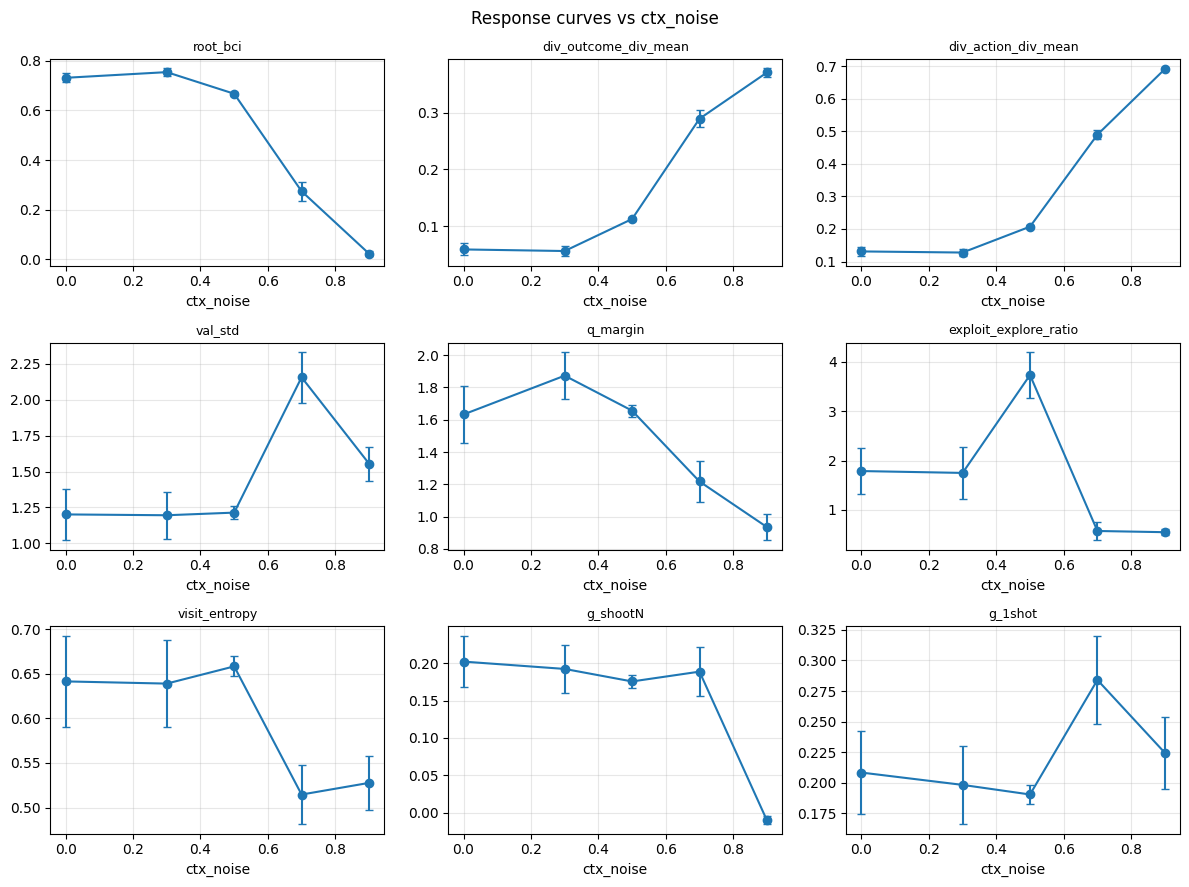

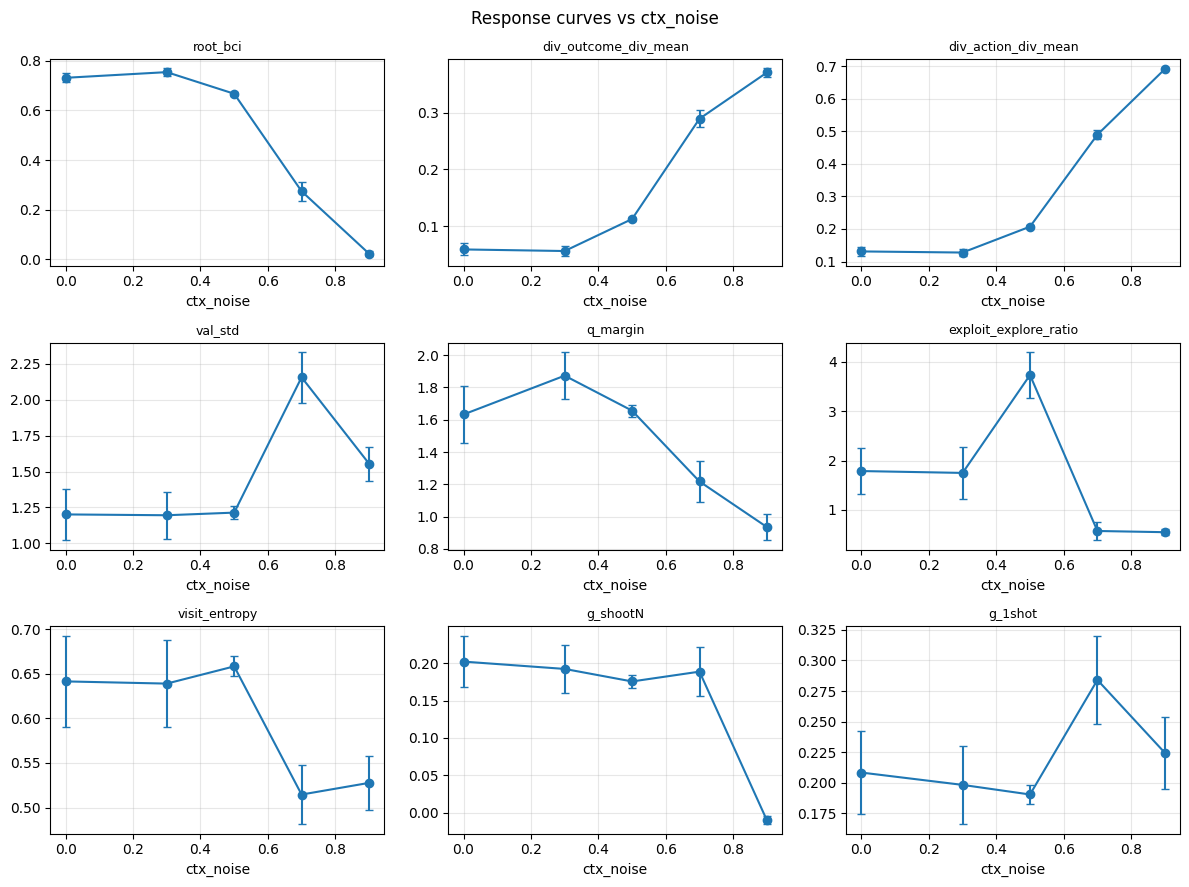

In [6]:
# change factor to any swept knob: 'horizon', 'max_depth', 'sim_horizon', ...
plots.response_curves(df, factor='ctx_noise')

## 4. Which tree metrics predict planning success?

- `spearman` — rank correlation with the outcome (monotone strength).
- `mutual_info` — catches **any** dependency; `mi >> |rho|` means a non-monotone link.
- `partial_vs_factors` — correlation **after controlling for every knob**. If this
  stays close to `spearman`, the metric is a genuine *online* signal rather than a
  proxy for the config.

In [7]:
tab = correlate.metric_outcome_table(df)
cols = ['metric', 'link', 'spearman', 'mutual_info', 'partial_vs_factors', 'p']
display(tab[tab.outcome == 'g_1shot'].head(15)[cols].round(3))

,metric,link,spearman,mutual_info,partial_vs_factors,p
41,edge_val_std,L2_diversity,0.565,0.742,0.503,0.0
42,val_spread,L3_value,0.520,0.472,0.481,0.0
43,val_std,L3_value,0.495,0.460,0.454,0.0
44,val_std_depth1,L3_value,0.495,0.460,0.454,0.0
45,visit_entropy,L4_selection,-0.477,0.351,-0.500,0.0
46,entropy_auc,L4_selection,-0.465,0.315,-0.493,0.0
47,commit_top1,L4_selection,0.464,0.273,0.493,0.0
48,subtree_size_gini,L5_structure,0.453,0.439,0.413,0.0
49,mean_visited_depth,L5_structure,0.423,0.260,0.436,0.0
50,exploit_explore_ratio,L4_selection,-0.412,0.362,-0.401,0.0


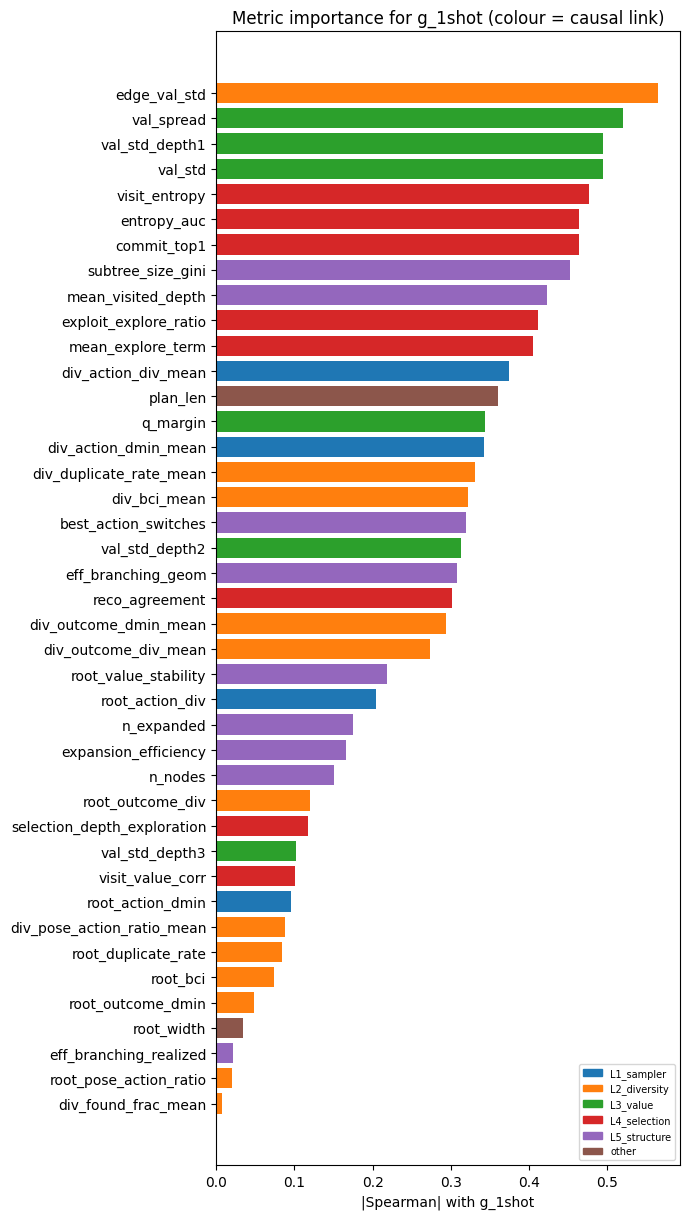

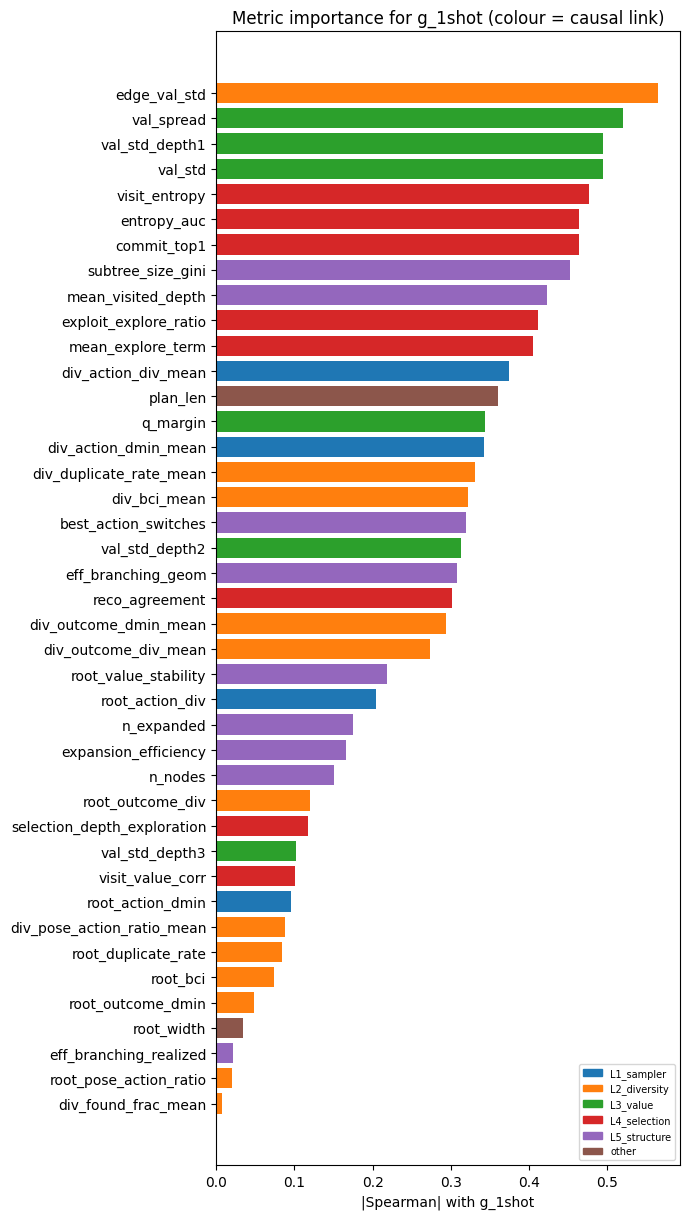

In [8]:
plots.link_importance_bars(df, 'g_1shot')

## 5. The mechanism — diverse edges ⇒ better, more reliable planning

Bin the trees by edge **reward diversity** and look at the outcome per bin. This is
the original hypothesis stated as a curve.

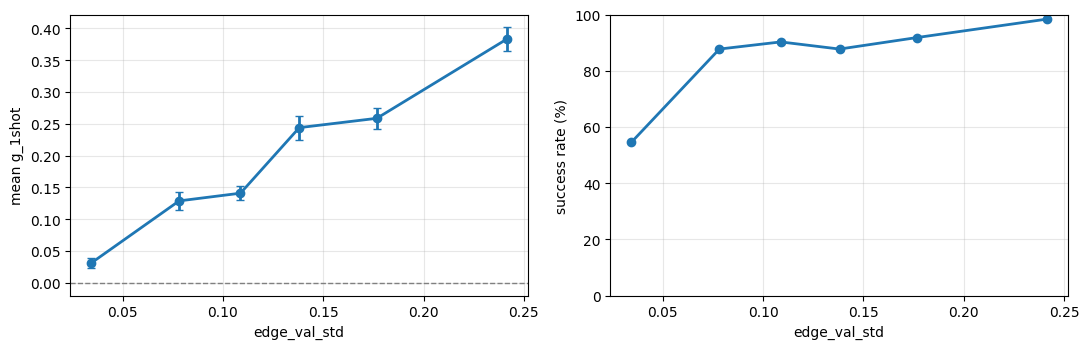

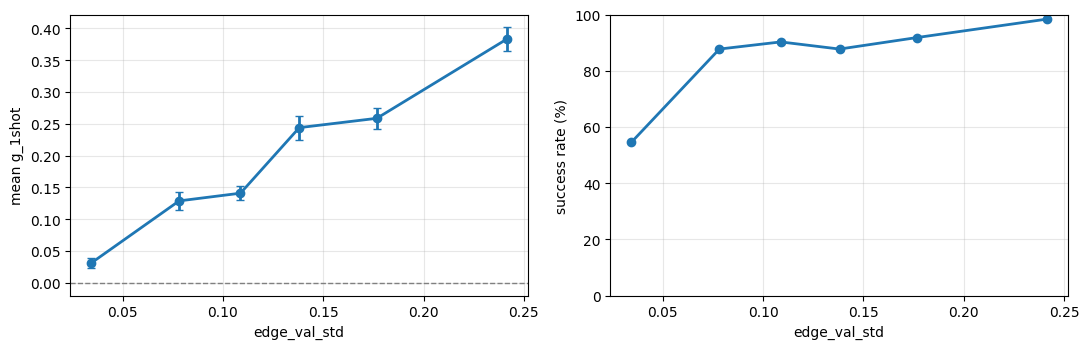

In [9]:
def mechanism(df, metric='edge_val_std', outcome='g_1shot', bins=6):
    '''Bin trees by `metric`; show mean outcome and success rate per bin.'''
    d = df[[metric, outcome, 'success_1shot']].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.assign(_b=pd.qcut(d[metric], bins, duplicates='drop'))
    g = d.groupby('_b', observed=True)
    x, y, e = g[metric].mean(), g[outcome].mean(), g[outcome].sem()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
    a1.axhline(0, color='grey', ls='--', lw=1)
    a1.errorbar(x, y, yerr=e, marker='o', lw=2, capsize=3)
    a1.set_xlabel(metric); a1.set_ylabel(f'mean {outcome}'); a1.grid(alpha=.3)
    a2.plot(x, 100 * g.success_1shot.mean(), marker='o', lw=2)
    a2.set_xlabel(metric); a2.set_ylabel('success rate (%)'); a2.set_ylim(0, 100); a2.grid(alpha=.3)
    fig.tight_layout(); return fig

mechanism(df)

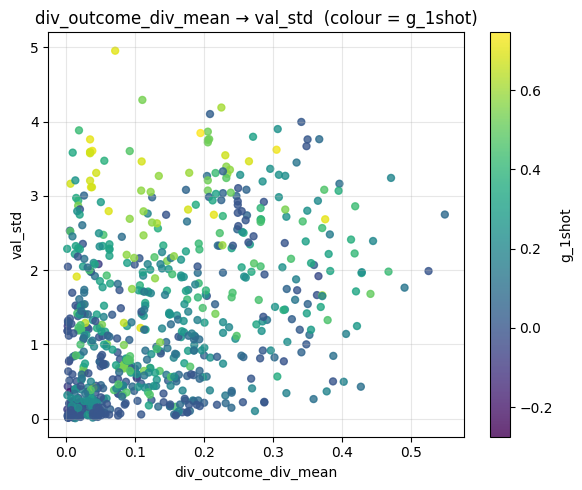

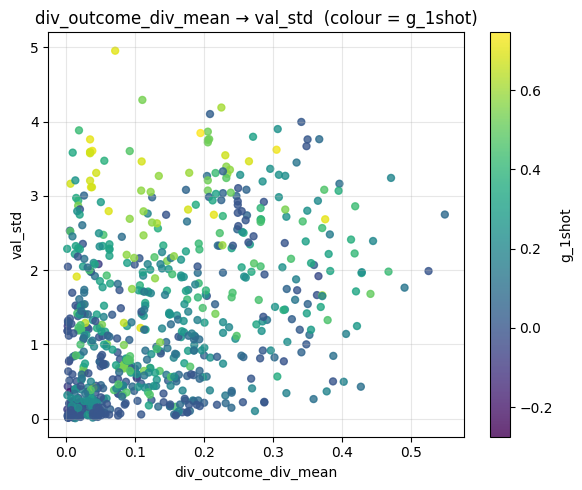

In [10]:
# per-tree view: diversity -> value separation, coloured by outcome
plots.mechanism_scatter(df)

## 6. Explore anything yourself

`curve(factor, metric)` — OFAT response of **any** metric vs **any** knob.  
`corr(metric, outcome)` — scatter + rank correlation + partial correlation.

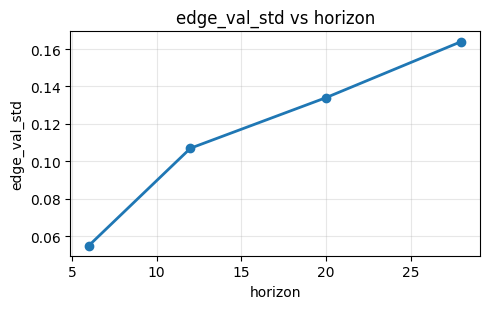

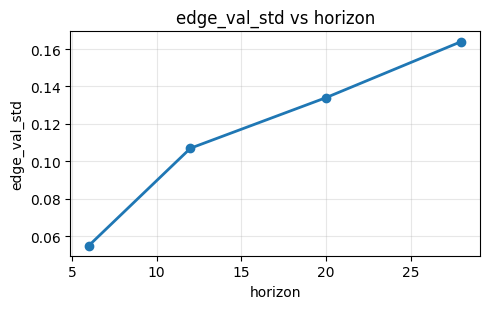

In [11]:
def curve(factor, metric='g_1shot'):
    '''OFAT response of ANY metric vs ANY swept factor.'''
    t = ofat(df, factor, [metric])
    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.errorbar(t.index, t[metric], marker='o', lw=2)
    ax.set_xlabel(factor); ax.set_ylabel(metric); ax.grid(alpha=.3)
    ax.set_title(f'{metric} vs {factor}'); fig.tight_layout(); return fig

def corr(metric, outcome='g_1shot'):
    '''Scatter + rank correlation + partial correlation (controlling for the knobs).'''
    ctrl = [c for c in schema.FACTORS if c in df and df[c].nunique() > 1]
    r = stats.spearmanr(df[metric], df[outcome], nan_policy='omit')[0]
    p = correlate.partial_spearman(df, metric, outcome, ctrl)
    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    ax.scatter(df[metric], df[outcome], s=12, alpha=.5)
    ax.axhline(0, color='grey', ls='--', lw=1)
    ax.set_xlabel(metric); ax.set_ylabel(outcome); ax.grid(alpha=.3)
    ax.set_title(f'rho={r:+.3f}   partial={p:+.3f}', fontsize=10)
    fig.tight_layout(); return fig

curve('horizon', 'edge_val_std')

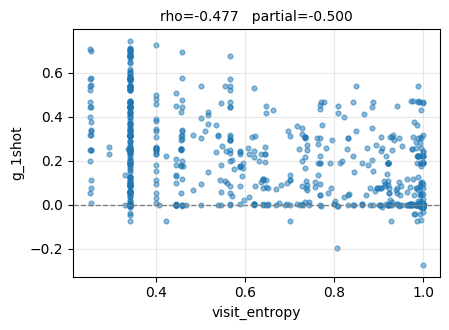

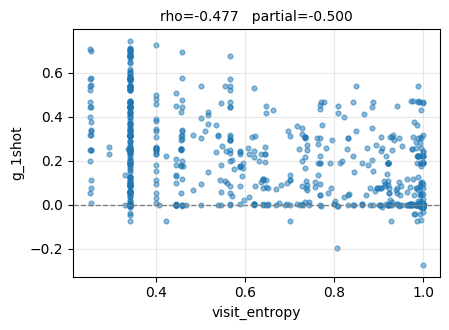

In [12]:
corr('visit_entropy')

In [13]:
# every metric you can pass to curve() / corr():
sorted(schema.process_cols(df))

['best_action_switches',
 'commit_top1',
 'div_action_div_mean',
 'div_action_dmin_mean',
 'div_bci_mean',
 'div_duplicate_rate_mean',
 'div_found_frac_mean',
 'div_outcome_div_mean',
 'div_outcome_dmin_mean',
 'div_pose_action_ratio_mean',
 'edge_val_std',
 'eff_branching_geom',
 'eff_branching_realized',
 'entropy_auc',
 'expansion_efficiency',
 'exploit_explore_ratio',
 'mean_explore_term',
 'mean_visited_depth',
 'n_expanded',
 'n_nodes',
 'plan_len',
 'q_margin',
 'reco_agreement',
 'root_action_div',
 'root_action_dmin',
 'root_bci',
 'root_duplicate_rate',
 'root_outcome_div',
 'root_outcome_dmin',
 'root_pose_action_ratio',
 'root_value_stability',
 'root_width',
 'selection_depth_exploration',
 'subtree_size_gini',
 'val_spread',
 'val_std',
 'val_std_depth1',
 'val_std_depth2',
 'val_std_depth3',
 'visit_entropy',
 'visit_value_corr']

## 7. Publication figures (the LaTeX deck)

The exact five figures embedded in the presentation, rendered **inline** here.

Each `fig_*(df, out)` writes `pdf`+`png` when `out` is a directory, or **returns the
figure when `out=None`** — so the notebook and the deck can never diverge.

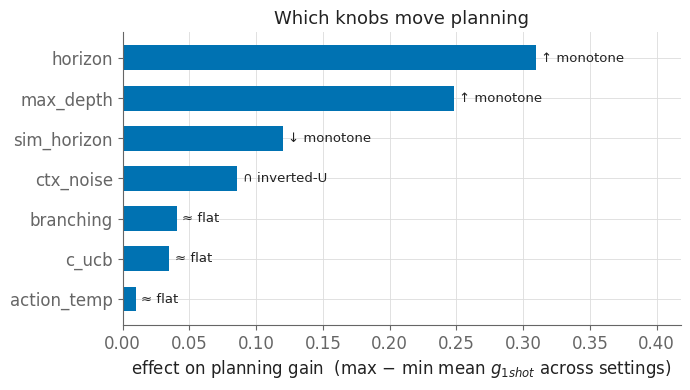

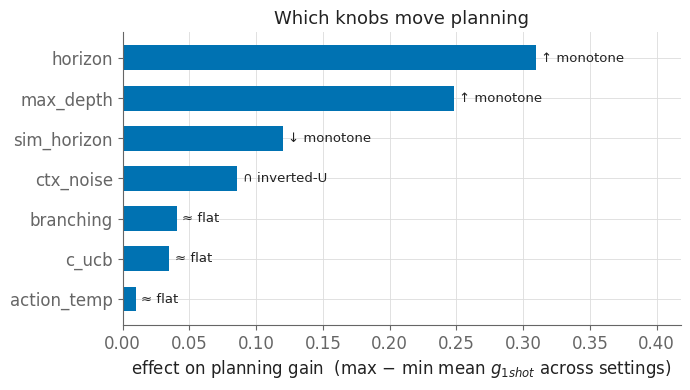

In [14]:
from dreamerv4uwm.planning.experiments.study.presentation import make_figures as mf

mf.fig_knob_effects(df, None)

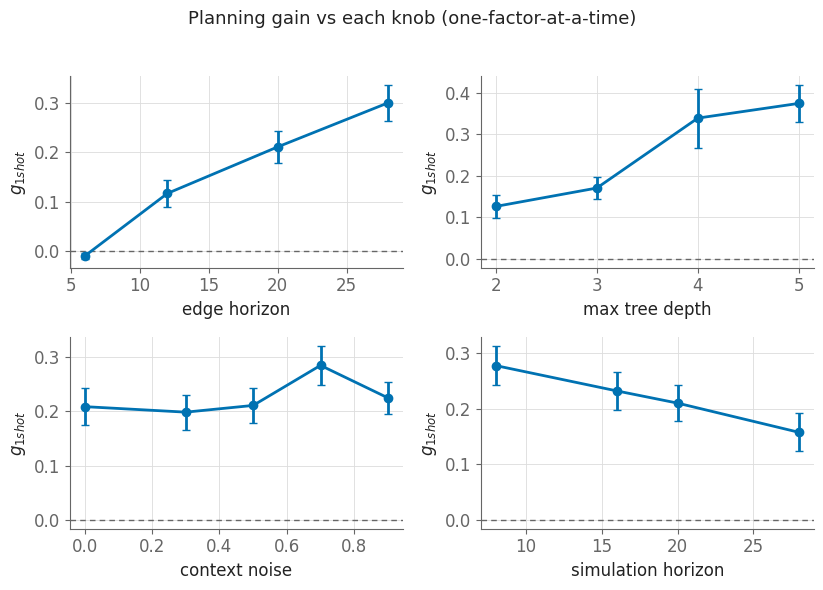

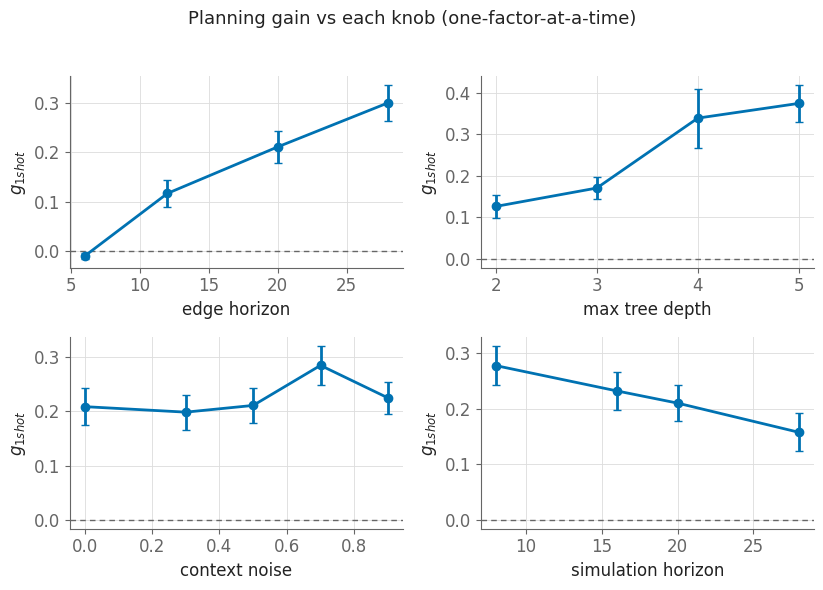

In [15]:
mf.fig_knob_curves(df, None)

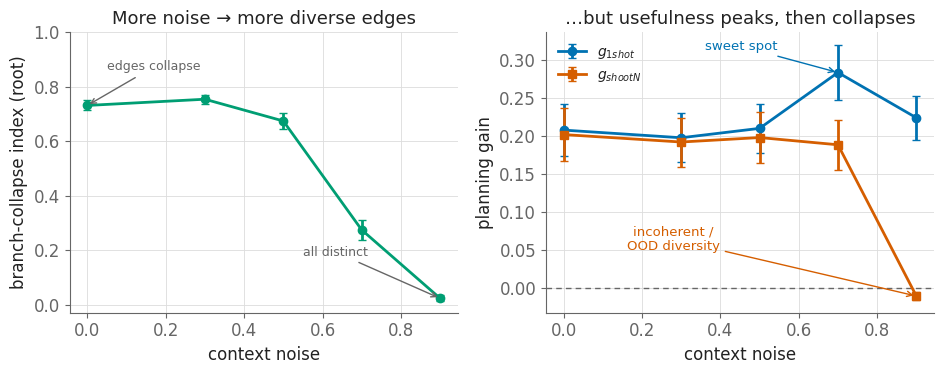

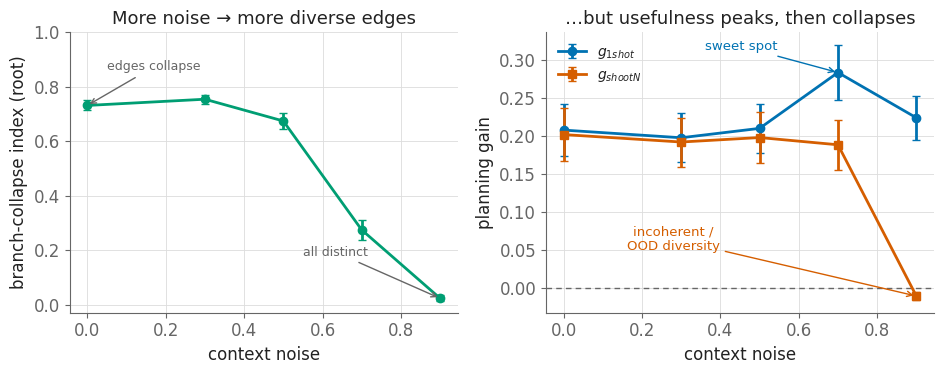

In [16]:
mf.fig_ctxnoise(df, None)

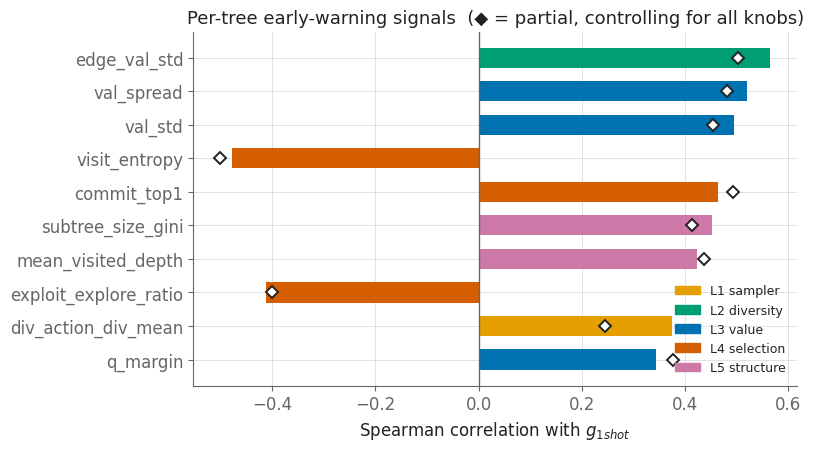

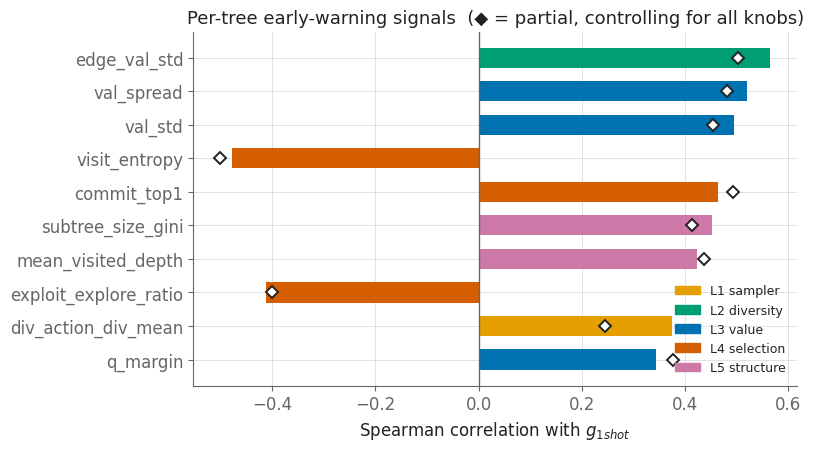

In [17]:
mf.fig_predictors(df, None)

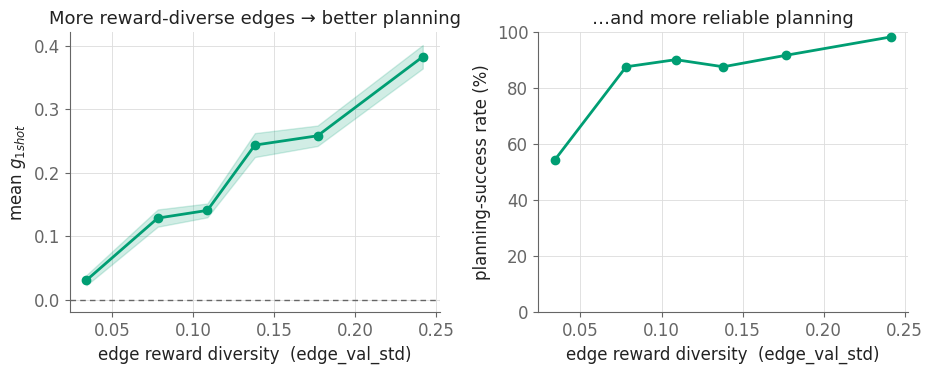

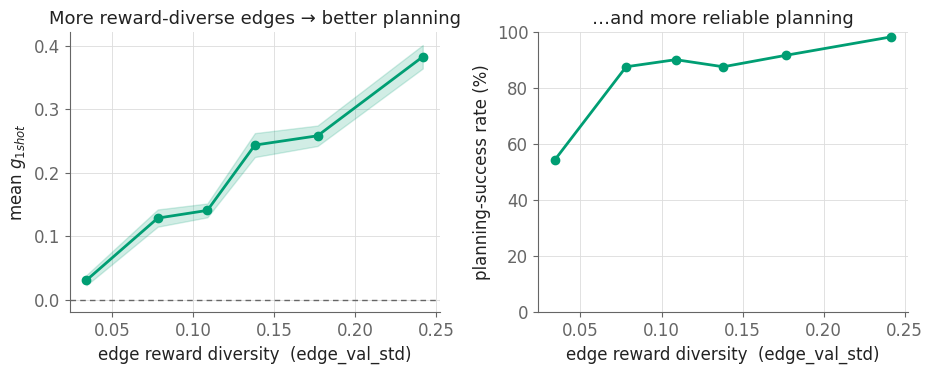

In [18]:
mf.fig_mechanism(df, None)

In [19]:
# the headline numbers quoted in the deck
print(mf.key_numbers(df, None))

rows=735  configs=21  inits=35
success_1shot_rate=0.850
horizon: g_1shot 6->-0.010, 12->+0.117, 20->+0.210, 28->+0.299
max_depth: g_1shot 2->+0.127, 3->+0.171, 4->+0.339, 5->+0.374
ctx_noise: g_1shot 0->+0.208, 0.3->+0.198, 0.5->+0.210, 0.7->+0.284, 0.9->+0.224
sim_horizon: g_1shot 8->+0.278, 16->+0.232, 20->+0.210, 28->+0.158
c_ucb: g_1shot 0.5->+0.210, 2->+0.220, 8->+0.185
edge_val_std: rho=+0.565 partial=+0.503
val_std: rho=+0.495 partial=+0.454
visit_entropy: rho=-0.477 partial=-0.500
exploit_explore_ratio: rho=-0.412 partial=-0.401
within-base edge_val_std: rho=+0.524 p=0.00125
within-base val_std: rho=+0.534 p=0.000949
within-base exploit_explore_ratio: rho=-0.459 p=0.0056



### Write them to disk

Uncomment to regenerate the PDFs the deck embeds (`../presentation/figures/`).

In [20]:
# OUT = '../presentation/figures'
# for fn in (mf.fig_knob_effects, mf.fig_knob_curves, mf.fig_ctxnoise,
#            mf.fig_predictors, mf.fig_mechanism):
#     fn(df, OUT)
# mf.key_numbers(df, OUT)